<a href="https://colab.research.google.com/github/ibrahimshehin2017-sketch/WEBSITE-/blob/main/FDS%20MICRO%20PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving sensor.csv to sensor (1).csv
             ts             device        co   humidity  light       lpg  \
0  1.594512e+09  b8:27:eb:bf:9d:51  0.004956  51.000000  False  0.007651   
1  1.594512e+09  00:0f:00:70:91:0a  0.002840  76.000000  False  0.005114   
2  1.594512e+09  b8:27:eb:bf:9d:51  0.004976  50.900000  False  0.007673   
3  1.594512e+09  1c:bf:ce:15:ec:4d  0.004403  76.800003   True  0.007023   
4  1.594512e+09  b8:27:eb:bf:9d:51  0.004967  50.900000  False  0.007664   

   motion     smoke       temp  
0   False  0.020411  22.700000  
1   False  0.013275  19.700001  
2   False  0.020475  22.600000  
3   False  0.018628  27.000000  
4   False  0.020448  22.600000  


/tmp/ipykernel_1352/3074261745.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')
/tmp/ipykernel_1352/3074261745.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


        temp   humidity  temp_diff  anomaly
0  22.700000  51.000000   0.000000        0
1  19.700001  76.000000  -2.999999        0
2  22.600000  50.900000   2.899999        0
3  27.000000  76.800003   4.400000        1
4  22.600000  50.900000  -4.400000        0


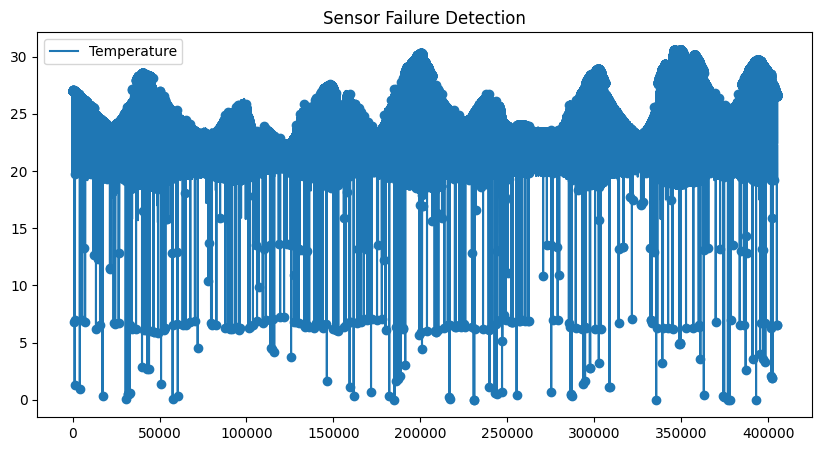

Starting Real-Time Detection...

Time 0: Normal
Time 1: Normal
Time 2: Normal
Time 3: ⚠️ Sensor Failure Detected
Time 4: Normal
Time 5: ⚠️ Sensor Failure Detected
Time 6: Normal
Time 7: Normal
Time 8: ⚠️ Sensor Failure Detected
Time 9: Normal
Time 10: Normal
Time 11: ⚠️ Sensor Failure Detected
Time 12: Normal
Time 13: ⚠️ Sensor Failure Detected
Time 14: Normal
Time 15: Normal
Time 16: Normal
Time 17: Normal
Time 18: ⚠️ Sensor Failure Detected
Time 19: Normal
Time 20: Normal
Time 21: ⚠️ Sensor Failure Detected
Time 22: Normal
Time 23: Normal
Time 24: Normal
Time 25: Normal
Time 26: ⚠️ Sensor Failure Detected
Time 27: Normal
Time 28: ⚠️ Sensor Failure Detected
Time 29: Normal
Time 30: Normal
Time 31: Normal
Time 32: ⚠️ Sensor Failure Detected
Time 33: Normal
Time 34: Normal
Time 35: Normal
Time 36: ⚠️ Sensor Failure Detected
Time 37: Normal
Time 38: Normal
Time 39: ⚠️ Sensor Failure Detected
Time 40: Normal
Time 41: Normal
Time 42: ⚠️ Sensor Failure Detected
Time 43: Normal
Time 44: Norm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import time
from google.colab import files
uploaded = files.upload()

# Upload your CSV in Colab
data = pd.read_csv("iot_telemetry_data.csv")

print(data.head())

data = data[['temp', 'humidity']] # Changed 'temperature' to 'temp' and removed 'pressure'
# Handle missing values
data = data.fillna(method='ffill')

# Feature Engineering
data['temp_diff'] = data['temp'].diff() # Changed 'temperature' to 'temp'
data = data.fillna(0)

# Normalize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(scaled_data)
# Handle missing values
data = data.fillna(method='ffill')

# Feature Engineering
data['temp_diff'] = data['temp'].diff() # Changed 'temperature' to 'temp'
data = data.fillna(0)

# Normalize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(scaled_data)
data['anomaly'] = model.predict(scaled_data)

# Convert output
data['anomaly'] = data['anomaly'].map({1: 0, -1: 1})

print(data.head())
plt.figure(figsize=(10,5))

plt.plot(data['temp'], label='Temperature') # Changed 'temperature' to 'temp'

anomalies = data[data['anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['temp']) # Changed 'temperature' to 'temp'

plt.title("Sensor Failure Detection")
plt.legend()
plt.show()
print("Starting Real-Time Detection...\n")

for i in range(len(scaled_data)):
    sample = scaled_data[i].reshape(1, -1)
    result = model.predict(sample)

    if result == -1:
        print(f"Time {i}: ⚠️ Sensor Failure Detected")
    else:
        print(f"Time {i}: Normal")

    time.sleep(0.5)
